In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.shape

(891, 12)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Duplicate Data

In [6]:
train[train.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [7]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Handle Missing Values

<Axes: >

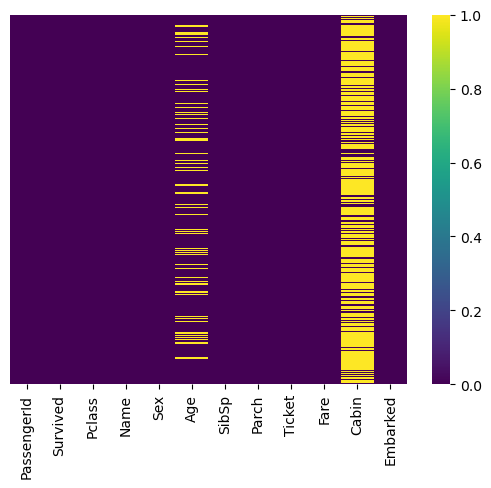

In [8]:
sns.heatmap(train.isnull(), yticklabels= False, cmap = 'viridis', cbar = True)

In [9]:
# since cabine has most of the missing values 687 out of 891 so we drop it

train.drop(['Cabin'], axis = 1, inplace= True)

In [10]:
train['Age'] = train['Age'].fillna(train['Age'].median())
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

# Removing Unwanted features that are not important

In [11]:
train.drop(['PassengerId', 'Name', 'Ticket'], axis = 1, inplace = True)

# Outliers

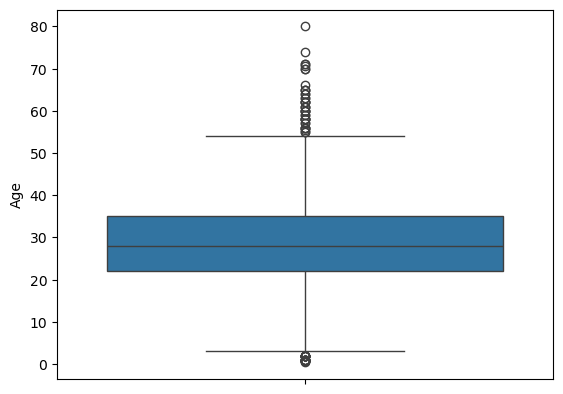

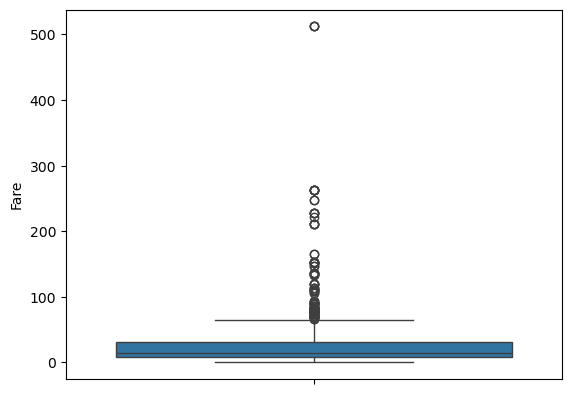

In [12]:
num_cols = ['Age','Fare']

for col in num_cols:
    sns.boxplot(y=train[col])
    plt.show()

In [13]:
from scipy.stats.mstats import winsorize

train['Age'] = winsorize(train['Age'], limits=[0.01,0.01])
train['Fare'] = winsorize(train['Fare'], limits=[0.01,0.01])

# Analysis

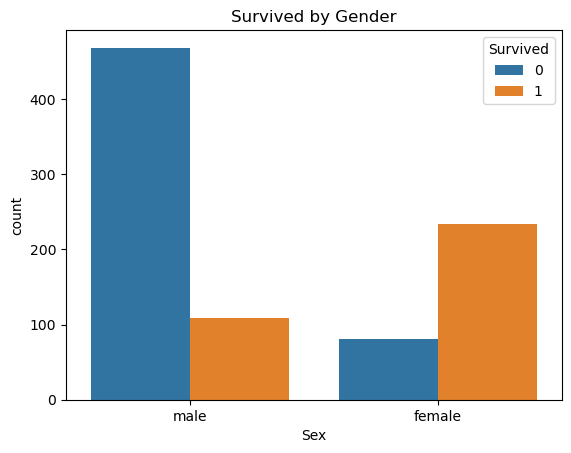

In [14]:
sns.countplot(data = train, x = 'Sex', hue = 'Survived')
plt.title('Survived by Gender')
plt.show()

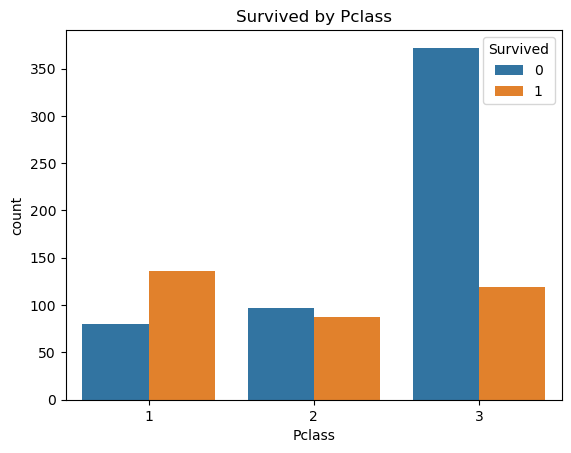

In [15]:
sns.countplot(data = train, x = 'Pclass', hue = 'Survived')
plt.title('Survived by Pclass')
plt.show()

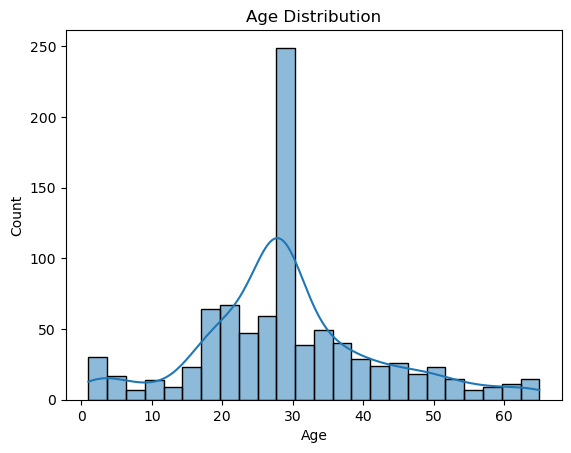

In [16]:
sns.histplot(train['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

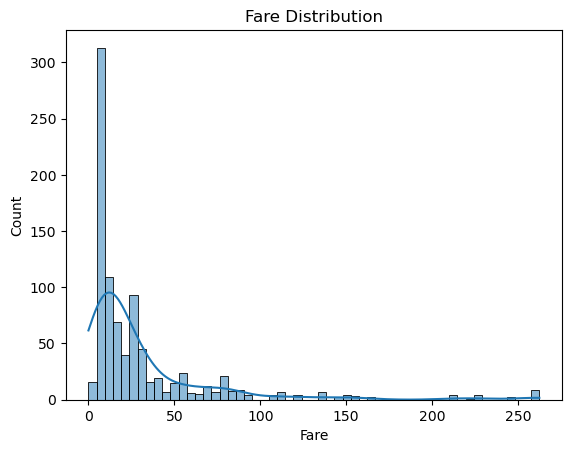

In [17]:
sns.histplot(train['Fare'], kde=True)
plt.title('Fare Distribution')
plt.show()

# Handle the categorical data

In [18]:
train_encoded = train.copy()

train_encoded['Sex'] = train_encoded['Sex'].map({'male':0,'female':1})
train_encoded['Embarked'] = train_encoded['Embarked'].astype('category').cat.codes

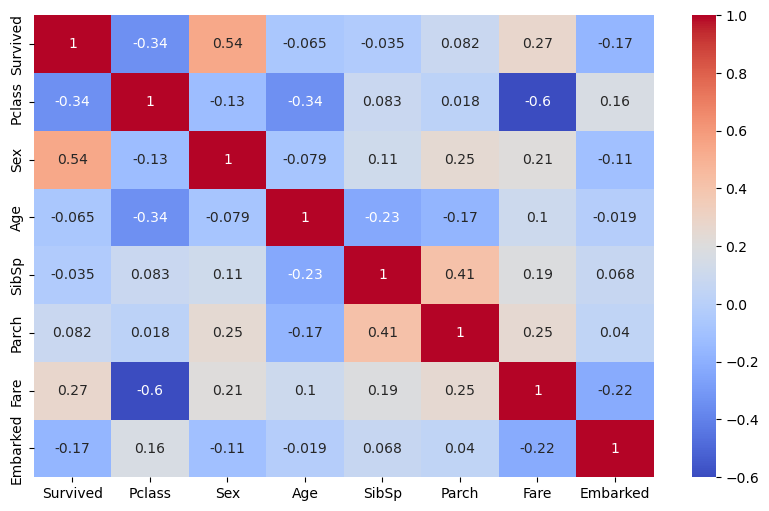

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(train_encoded.corr(),
            annot=True,
            cmap='coolwarm')
plt.show()

# Observations
### Finding 1
    Female passengers had much higher survival rates than males.

### Finding 2
    Passengers traveling in first class had the highest survival probability.

### Finding 3
    Higher ticket fares were associated with higher survival rates.

### Finding 4
    The majority of passengers were adults aged 20–40.

### Finding 5
    Passenger class and fare appear to be important predictors of survival.

These observations suggest that socioeconomic status and gender played major roles in survival outcomes during the disaster.